# Featuring Engineering, Split, Impute, Encode, Scale

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lightgbm as lgb
import time
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import IterativeStratification
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_parquet("C:/Documents/VSCODE/Final FYP Code (ADESight)/ADR Data & Modelling Pipeline/data/adverse_events_drug_level_new.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122923 entries, 0 to 122922
Data columns (total 24 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   caseid                            122923 non-null  int64  
 1   occr_country                      120694 non-null  object 
 2   sex_clean                         108146 non-null  object 
 3   age_yrs_clean                     91010 non-null   float64
 4   drug_PREDNISONE                   122923 non-null  int8   
 5   drug_DUPILUMAB                    122923 non-null  int8   
 6   drug_RITUXIMAB                    122923 non-null  int8   
 7   drug_METHOTREXATE                 122923 non-null  int8   
 8   drug_INFLIXIMAB-DYYB              122923 non-null  int8   
 9   drug_VEDOLIZUMAB                  122923 non-null  int8   
 10  drug_ACETAMINOPHEN                122923 non-null  int8   
 11  drug_TIRZEPATIDE                  122923 non-null  i

In [4]:
df.head()

,caseid,occr_country,sex_clean,age_yrs_clean,drug_PREDNISONE,drug_DUPILUMAB,drug_RITUXIMAB,drug_METHOTREXATE,drug_INFLIXIMAB-DYYB,drug_VEDOLIZUMAB,...,reaction_DIARRHOEA,reaction_RASH,reaction_NAUSEA,reaction_DYSPNOEA,reaction_INFECTION,reaction_PSYCHIATRIC_EVENT,reaction_FATIGUE,reaction_DEATH,reaction_INJECTION_SITE_REACTION,reaction_HEADACHE
0,26208151,EU,M,30.0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,25629271,US,F,5.0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,24821429,US,F,48.0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,25505008,None,F,62.0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,25951083,US,None,56.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### 1. Feature Engineering

In [5]:
drug_cols = [c for c in df.columns if c.startswith("drug_")]
reaction_cols = [c for c in df.columns if c.startswith("reaction_")]

In [6]:
df["num_drugs"] = df[drug_cols].sum(axis=1)

In [7]:
df.head()

,caseid,occr_country,sex_clean,age_yrs_clean,drug_PREDNISONE,drug_DUPILUMAB,drug_RITUXIMAB,drug_METHOTREXATE,drug_INFLIXIMAB-DYYB,drug_VEDOLIZUMAB,...,reaction_RASH,reaction_NAUSEA,reaction_DYSPNOEA,reaction_INFECTION,reaction_PSYCHIATRIC_EVENT,reaction_FATIGUE,reaction_DEATH,reaction_INJECTION_SITE_REACTION,reaction_HEADACHE,num_drugs
0,26208151,EU,M,30.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1,25629271,US,F,5.0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,24821429,US,F,48.0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,25505008,None,F,62.0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
4,25951083,US,None,56.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1


### 2. Split

In [8]:
# Replace "None" strings with np.nan before building X
df["sex_clean"]    = df["sex_clean"].astype(object).where(df["sex_clean"].notna(), other=np.nan)
df["occr_country"] = df["occr_country"].astype(object).where(df["occr_country"].notna(), other=np.nan)

# Then rebuild X
feature_cols = ["age_yrs_clean", "num_drugs", "sex_clean", "occr_country"] + drug_cols
X            = df[feature_cols].values
y            = df[reaction_cols].values

In [9]:
# ── Modified split function ───────────────────────────────────────
def iterative_split(X, y, test_size):
    stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[test_size, 1.0-test_size])
    train_indices, test_indices = next(stratifier.split(X, y))
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices], train_indices, test_indices

# ── Split 1: 80% train+val, 20% test ─────────────────────────────
X_train_val, X_test, y_train_val, y_test, idx_train_val, idx_test = iterative_split(X, y, test_size=0.2)

# ── Split 2: 75% train, 25% val ──────────────────────────────────
X_train, X_val, y_train, y_val, idx_train_rel, idx_val_rel = iterative_split(X_train_val, y_train_val, test_size=0.25)

# resolve val indices back to original df indices
idx_train = idx_train_val[idx_train_rel]
idx_val   = idx_train_val[idx_val_rel]

### 3. Impute (on train only)

In [10]:
# ── Missing values check after split and imputation ───────────────

def check_missing(arr, name, cols):
    df_check = pd.DataFrame(arr, columns=cols)
    missing  = df_check.isna().mean() * 100
    missing  = missing[missing > 0].sort_values(ascending=False)
    print(f"\n{name} — shape: {arr.shape}")
    if len(missing) == 0:
        print("  No missing values ✓")
    else:
        print(missing.to_string())

# Current feature cols (before encoding, only what's in X)
check_missing(X_train, "X_train", feature_cols)
check_missing(X_val,   "X_val",   feature_cols)
check_missing(X_test,  "X_test",  feature_cols)


X_train — shape: (73920, 14)
age_yrs_clean    25.845509
sex_clean        12.095509
occr_country      1.795184

X_val — shape: (24482, 14)
age_yrs_clean    26.129401
sex_clean        12.045585
occr_country      1.858508

X_test — shape: (24521, 14)
age_yrs_clean    26.144937
sex_clean        11.773582
occr_country      1.822927


In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor

age_idx     = feature_cols.index('age_yrs_clean')
sex_idx     = feature_cols.index('sex_clean')
country_idx = feature_cols.index('occr_country')

X_train_rf = X_train.copy()
X_val_rf   = X_val.copy()
X_test_rf  = X_test.copy()

# RF iterative for age
imputer_age = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1),
    max_iter=5,
    random_state=42
)
X_train_rf[:, age_idx] = imputer_age.fit_transform(X_train_rf[:, [age_idx]]).ravel()
X_val_rf[:, age_idx]   = imputer_age.transform(X_val_rf[:, [age_idx]]).ravel()
X_test_rf[:, age_idx]  = imputer_age.transform(X_test_rf[:, [age_idx]]).ravel()

# Mode for sex
imputer_sex = SimpleImputer(strategy='most_frequent')
X_train_rf[:, sex_idx] = imputer_sex.fit_transform(X_train_rf[:, [sex_idx]]).ravel()
X_val_rf[:, sex_idx]   = imputer_sex.transform(X_val_rf[:, [sex_idx]]).ravel()
X_test_rf[:, sex_idx]  = imputer_sex.transform(X_test_rf[:, [sex_idx]]).ravel()

# Mode for country
imputer_country = SimpleImputer(strategy='most_frequent')
X_train_rf[:, country_idx] = imputer_country.fit_transform(X_train_rf[:, [country_idx]]).ravel()
X_val_rf[:, country_idx]   = imputer_country.transform(X_val_rf[:, [country_idx]]).ravel()
X_test_rf[:, country_idx]  = imputer_country.transform(X_test_rf[:, [country_idx]]).ravel()

# Overwrite originals
X_train = X_train_rf
X_val   = X_val_rf
X_test  = X_test_rf

In [12]:
check_missing(X_train, "X_train", feature_cols)
check_missing(X_val,   "X_val",   feature_cols)
check_missing(X_test,  "X_test",  feature_cols)


X_train — shape: (73920, 14)
  No missing values ✓

X_val — shape: (24482, 14)
  No missing values ✓

X_test — shape: (24521, 14)
  No missing values ✓


In [13]:
print(pd.Series(X_train[:, sex_idx]).unique())
print(pd.Series(X_train[:, country_idx]).unique())

['F' 'M']
['US' 'FR' 'CA' 'DE' 'BE' 'GB' 'TW' 'EU' 'JP' 'BR' 'CO' 'PL' 'AU' 'CH'
 'ES' 'KR' 'TR' 'RS' 'CN' 'SG' 'TH' 'PK' 'IR' 'EG' 'IN' 'MX' 'SE' 'IL'
 'KP' 'AT' 'NL' 'PT' 'IT' 'SK' 'ZA' 'AR' 'JO' 'IE' 'HK' 'QA' 'DZ' 'RU'
 'PR' 'CL' 'ID' 'NO' 'AE' 'HU' 'NZ' 'HR' 'SA' 'GR' 'MY' 'LV' 'MA' 'IQ'
 'RO' 'FI' 'PE' 'NG' 'GE' 'DK' 'LB' 'KW' 'EE' 'DO' 'CZ' 'LK' 'PS' 'AM'
 'VN' 'CR' 'LU' 'PH' 'TN' 'JM' 'VE' 'EC' 'ME' 'BD' 'MK' 'KZ' 'LT' 'UY'
 'UZ' 'PY' 'NP' 'SI' 'OM' 'UA' 'AL' 'BY' 'IS' 'BG' 'AZ' 'LC' 'PA' 'TZ']


### 4. Encode (on train only)

In [14]:
# ── Encoding ──────────────────────────────────────────────────────

# 4. Encode sex (F=0, M=1)
sex_map = {"F": 0, "M": 1}

X_train[:, sex_idx] = np.array([sex_map[s] for s in X_train[:, sex_idx]])
X_val[:, sex_idx]   = np.array([sex_map[s] for s in X_val[:, sex_idx]])
X_test[:, sex_idx]  = np.array([sex_map[s] for s in X_test[:, sex_idx]])

# 5. Frequency encode country (fit on train only)
country_freq = pd.Series(X_train[:, country_idx]).value_counts(normalize=True)

X_train[:, country_idx] = pd.Series(X_train[:, country_idx]).map(country_freq).fillna(0).values.astype(float)
X_val[:, country_idx]   = pd.Series(X_val[:, country_idx]).map(country_freq).fillna(0).values.astype(float)
X_test[:, country_idx]  = pd.Series(X_test[:, country_idx]).map(country_freq).fillna(0).values.astype(float)

# Convert all to float
X_train = X_train.astype(float)
X_val   = X_val.astype(float)
X_test  = X_test.astype(float)

# Update feature col names to reflect encoding
feature_cols[sex_idx]     = "sex_encoded"
feature_cols[country_idx] = "country_freq_encoded"

In [15]:
# ── Verify encoding ──────────────────────────────────────────────

# Convert to dataframe for readable output
df_check = pd.DataFrame(X_train, columns=feature_cols)

# Check sex encoding
print("Sex encoding:")
print(df_check["sex_encoded"].value_counts())
print()

# Check country freq encoding
print("Country frequency encoding:")
print(df_check["country_freq_encoded"].describe())
print()
print("Sample values:")
print(df_check["country_freq_encoded"].head(10))

Sex encoding:
sex_encoded
0.0    52715
1.0    21205
Name: count, dtype: int64

Country frequency encoding:
count    73920.000000
mean         0.523928
std          0.280436
min          0.000014
25%          0.161607
50%          0.703964
75%          0.703964
max          0.703964
Name: country_freq_encoded, dtype: float64

Sample values:
0    0.703964
1    0.703964
2    0.703964
3    0.703964
4    0.703964
5    0.703964
6    0.007332
7    0.703964
8    0.703964
9    0.161607
Name: country_freq_encoded, dtype: float64


### 5. Feature Importance (on X_train only)

In [23]:
def aggregate_importances(importance_series, col_group_map):
    agg = {}
    for orig_col, dummy_cols in col_group_map.items():
        present = [c for c in dummy_cols if c in importance_series.index]
        agg[orig_col] = importance_series[present].sum() if present else 0.0
    return pd.Series(agg).sort_values(ascending=False)

def plot_importance(series, title):
    df_plot = series.sort_values(ascending=True).reset_index()
    df_plot.columns = ['feature', 'importance']
    plt.figure(figsize=(8, max(5, 0.35 * len(df_plot))))
    ax = sns.barplot(x='importance', y='feature', data=df_plot, palette='viridis')
    ax.invert_yaxis()
    plt.title(title)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

In [17]:
# ── Feature Importance (on X_train only) ─────────────────────────

# 1. Convert X_train to DataFrame
X_train_df = pd.DataFrame(X_train, columns=feature_cols)
y_train_df = y_train

# col_group_map — each feature maps to itself since already encoded
col_group_map = {col: [col] for col in feature_cols}

In [18]:
# 2. Random Forest
rf       = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
multi_rf = MultiOutputClassifier(rf)
multi_rf.fit(X_train_df, y_train_df)

rf_raw = pd.Series(
    np.mean([est.feature_importances_ for est in multi_rf.estimators_], axis=0),
    index=feature_cols
)

In [19]:
# 3. LightGBM
lgb_models = []
for i in range(y_train_df.shape[1]):
    clf = lgb.LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    clf.fit(X_train_df, y_train_df[:, i])
    lgb_models.append(clf)

lgb_raw = pd.Series(
    np.mean([m.feature_importances_ for m in lgb_models], axis=0),
    index=feature_cols
)

[LightGBM] [Info] Number of positive: 9092, number of negative: 64828
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 183
[LightGBM] [Info] Number of data points in the train set: 73920, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122998 -> initscore=-1.964343
[LightGBM] [Info] Start training from score -1.964343
[LightGBM] [Info] Number of positive: 14533, number of negative: 59387
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 183
[LightGBM] [Info] Number of data points in the train set: 73920, number of used features: 14
[LightGBM] [Info] [bi

In [20]:
# 4. SHAP
shap_matrices = []
for m in lgb_models:
    explainer = shap.TreeExplainer(m)
    sv        = explainer.shap_values(X_train_df)
    sv        = sv[1] if isinstance(sv, list) else sv
    shap_matrices.append(np.abs(sv).mean(axis=0))

shap_raw = pd.Series(
    np.mean(shap_matrices, axis=0),
    index=feature_cols
)

C:\Users\Alyssa\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Alyssa\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Alyssa\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Alyssa\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Alyssa\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM b

In [21]:
# 5. Mutual Information
mi_matrices = []
for i in range(y_train_df.shape[1]):
    mi = mutual_info_classif(X_train_df, y_train_df[:, i], discrete_features='auto', random_state=42)
    mi_matrices.append(mi)

mi_raw = pd.Series(
    np.mean(mi_matrices, axis=0),
    index=feature_cols
)

C:\Users\Alyssa\AppData\Local\Temp\ipykernel_31292\122322679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance', y='feature', data=df_plot, palette='viridis')


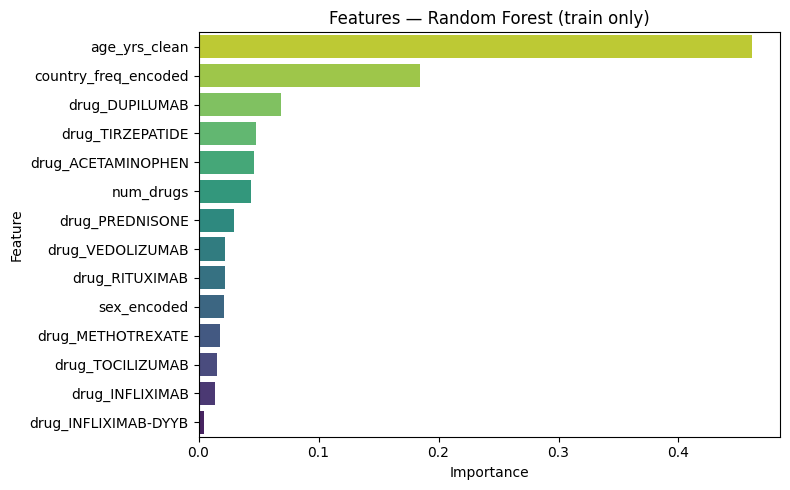

C:\Users\Alyssa\AppData\Local\Temp\ipykernel_31292\122322679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance', y='feature', data=df_plot, palette='viridis')


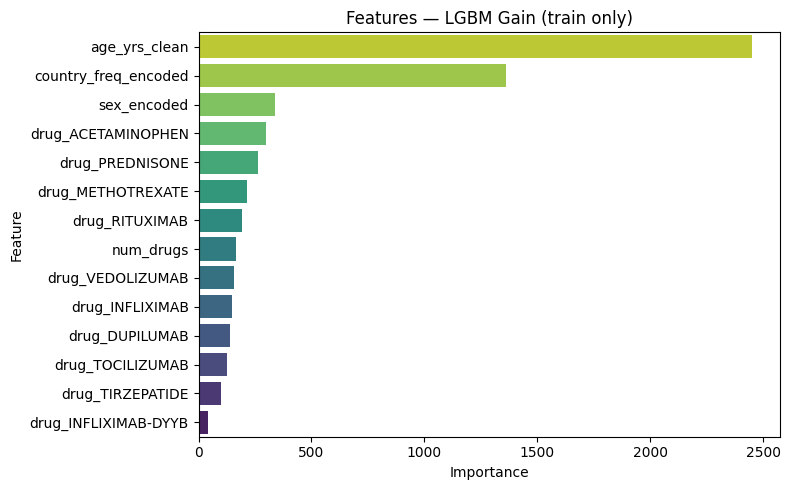

C:\Users\Alyssa\AppData\Local\Temp\ipykernel_31292\122322679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance', y='feature', data=df_plot, palette='viridis')


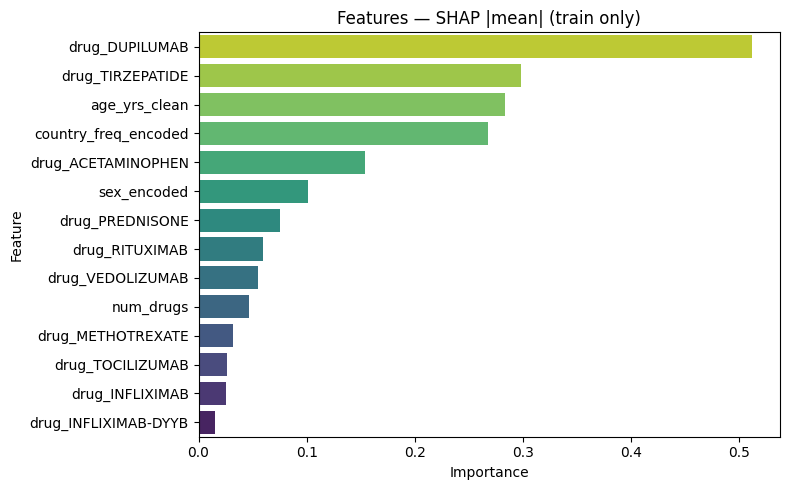

C:\Users\Alyssa\AppData\Local\Temp\ipykernel_31292\122322679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance', y='feature', data=df_plot, palette='viridis')


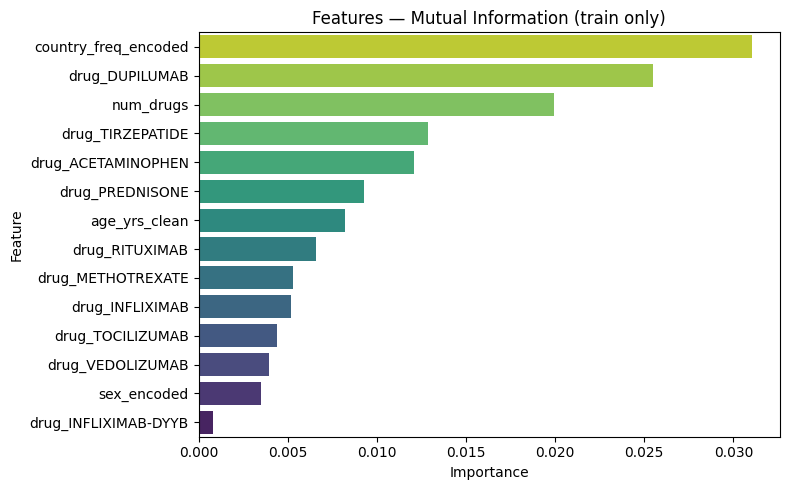

In [24]:
# 6. Aggregate
rf_agg   = aggregate_importances(rf_raw,   col_group_map)
lgb_agg  = aggregate_importances(lgb_raw,  col_group_map)
shap_agg = aggregate_importances(shap_raw, col_group_map)
mi_agg   = aggregate_importances(mi_raw,   col_group_map)

# 7. Plot
plot_importance(rf_raw,   'Features — Random Forest (train only)')
plot_importance(lgb_raw,  'Features — LGBM Gain (train only)')
plot_importance(shap_raw, 'Features — SHAP |mean| (train only)')
plot_importance(mi_raw,   'Features — Mutual Information (train only)')

In [25]:
# 8. Rank
rank_df = pd.DataFrame({
    'RF':   rf_agg.rank(ascending=False),
    'LGBM': lgb_agg.rank(ascending=False),
    'SHAP': shap_agg.rank(ascending=False),
    'MI':   mi_agg.rank(ascending=False),
}, index=list(col_group_map.keys()))

rank_df['mean_rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('mean_rank')

print("\n=== Feature Importance Consensus Ranking ===")
print(rank_df.round(1).to_string())


=== Feature Importance Consensus Ranking ===
                        RF  LGBM  SHAP    MI  mean_rank
country_freq_encoded   2.0   2.0   4.0   1.0        2.2
age_yrs_clean          1.0   1.0   3.0   7.0        3.0
drug_DUPILUMAB         3.0  11.0   1.0   2.0        4.2
drug_ACETAMINOPHEN     5.0   4.0   5.0   5.0        4.8
drug_TIRZEPATIDE       4.0  13.0   2.0   4.0        5.8
drug_PREDNISONE        7.0   5.0   7.0   6.0        6.2
num_drugs              6.0   8.0  10.0   3.0        6.8
sex_encoded           10.0   3.0   6.0  13.0        8.0
drug_RITUXIMAB         9.0   7.0   8.0   8.0        8.0
drug_METHOTREXATE     11.0   6.0  11.0   9.0        9.2
drug_VEDOLIZUMAB       8.0   9.0   9.0  12.0        9.5
drug_INFLIXIMAB       13.0  10.0  13.0  10.0       11.5
drug_TOCILIZUMAB      12.0  12.0  12.0  11.0       11.8
drug_INFLIXIMAB-DYYB  14.0  14.0  14.0  14.0       14.0


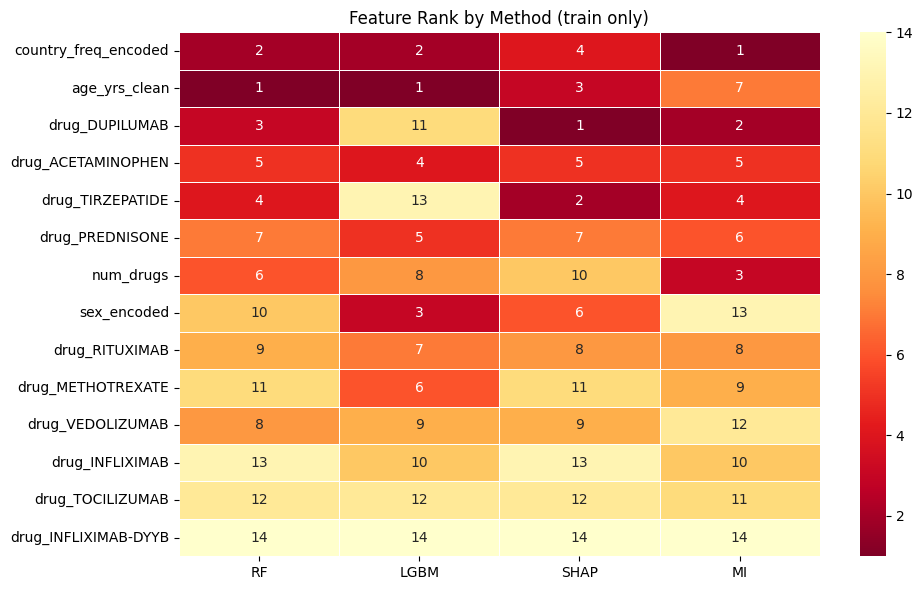

In [26]:
# 9. Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    rank_df.drop(columns='mean_rank').head(15),
    annot=True, fmt='.0f', cmap='YlOrRd_r',
    linewidths=0.5
)
plt.title('Feature Rank by Method (train only)')
plt.tight_layout()
plt.show()

### 6. Scale (on train only)

In [27]:
# ── Scaling ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [28]:
# Check scaling result
df_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
print(df_scaled.describe().round(3))

       age_yrs_clean  num_drugs  sex_encoded  country_freq_encoded  \
count      73920.000  73920.000    73920.000             73920.000   
mean           0.000     -0.000        0.000                -0.000   
std            1.000      1.000        1.000                 1.000   
min           -2.847     -0.320       -0.634                -1.868   
25%           -0.397     -0.320       -0.634                -1.292   
50%            0.000     -0.320       -0.634                 0.642   
75%            0.661     -0.320        1.577                 0.642   
max            2.722      6.936        1.577                 0.642   

       drug_PREDNISONE  drug_DUPILUMAB  drug_RITUXIMAB  drug_METHOTREXATE  \
count        73920.000       73920.000       73920.000          73920.000   
mean             0.000          -0.000           0.000             -0.000   
std              1.000           1.000           1.000              1.000   
min             -0.457          -0.761          -0.297       

### 7. Exporting Data Splits and FItted Transformer

In [29]:
# ── Save splits ───────────────────────────────────────────────────
import os
SAVE_DIR = "../output"  # Local directory at project root
os.makedirs(SAVE_DIR, exist_ok=True)

# Unscaled (for tree-based models: DT, RF, XGBoost, LightGBM)
np.save(f"{SAVE_DIR}/X_train.npy", X_train)
np.save(f"{SAVE_DIR}/X_val.npy",   X_val)
np.save(f"{SAVE_DIR}/X_test.npy",  X_test)

# Scaled (for Logistic Regression)
np.save(f"{SAVE_DIR}/X_train_scaled.npy", X_train_scaled)
np.save(f"{SAVE_DIR}/X_val_scaled.npy",   X_val_scaled)
np.save(f"{SAVE_DIR}/X_test_scaled.npy",  X_test_scaled)

# Labels (same for all models)
np.save(f"{SAVE_DIR}/y_train.npy", y_train)
np.save(f"{SAVE_DIR}/y_val.npy",   y_val)
np.save(f"{SAVE_DIR}/y_test.npy",  y_test)

# Save feature and reaction col names for reference
import json
with open(f"{SAVE_DIR}/feature_cols.json", "w") as f:
    json.dump(feature_cols, f)
with open(f"{SAVE_DIR}/reaction_cols.json", "w") as f:
    json.dump(reaction_cols, f)

print("✓ All splits saved. Ready for model training.")

✓ All splits saved. Ready for model training.


In [30]:
import joblib

# Save fitted transformers
joblib.dump(imputer_age,     f"{SAVE_DIR}/imputer_age.pkl")
joblib.dump(imputer_sex,     f"{SAVE_DIR}/imputer_sex.pkl")
joblib.dump(imputer_country, f"{SAVE_DIR}/imputer_country.pkl")
joblib.dump(scaler,          f"{SAVE_DIR}/scaler.pkl")
joblib.dump(country_freq,    f"{SAVE_DIR}/country_freq.pkl")

print("✓ Fitted transformers saved.")

✓ Fitted transformers saved.


In [31]:
with open(f"{SAVE_DIR}/reaction_cols.json", "w") as f:
    json.dump(reaction_cols, f)
with open(f"{SAVE_DIR}/drug_cols.json", "w") as f:
    json.dump(drug_cols, f)
print("✓ Column names saved.")

✓ Column names saved.
